In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
df = pd.read_csv('Apple_Stock.csv')
df.head()

,Date,Close/Last,Volume,Open,High,Low
0,02/28/2020,$273.36,106721200,$257.26,$278.41,$256.37
1,02/27/2020,$273.52,80151380,$281.1,$286,$272.96
2,02/26/2020,$292.65,49678430,$286.53,$297.88,$286.5
3,02/25/2020,$288.08,57668360,$300.95,$302.53,$286.13
4,02/24/2020,$298.18,55548830,$297.26,$304.18,$289.23


In [3]:
df.drop([' Volume', ' Open', ' High', ' Low'], axis=1, inplace=True)
df.head()

,Date,Close/Last
0,02/28/2020,$273.36
1,02/27/2020,$273.52
2,02/26/2020,$292.65
3,02/25/2020,$288.08
4,02/24/2020,$298.18


In [4]:
df.columns = df.columns.str.strip()
df.columns

Index(['Date', 'Close/Last'], dtype='object')

In [5]:
df['Close/Last'] = df['Close/Last'].replace('[\$,]', '', regex=True).astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
C:\Users\admin\AppData\Local\Temp\ipykernel_16424\2548826300.py:1: SyntaxWarning: invalid escape sequence '\$'
  df['Close/Last'] = df['Close/Last'].replace('[\$,]', '', regex=True).astype(float)


In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

In [7]:
df.set_index('Date', inplace=True)

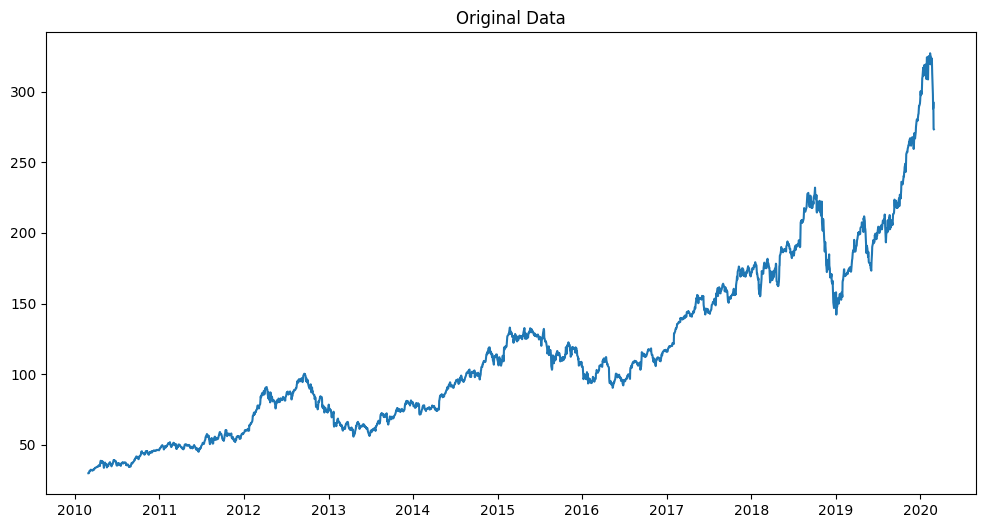

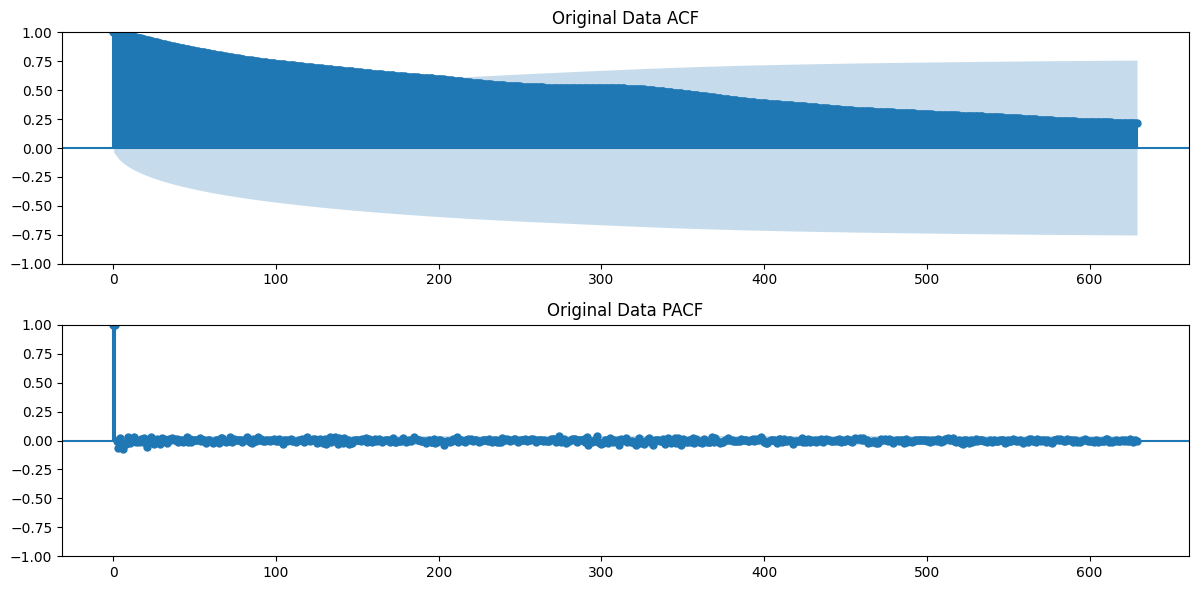

In [8]:
N=1000
plt.rcParams['figure.figsize'] = [12, 6]
X=df['Close/Last']
plt.plot(X)
plt.title('Original Data')
plt.show()
plt.subplot(2, 1, 1)
plot_acf(X, lags=len(X)/4, ax=plt.gca())
plt.title('Original Data ACF')
plt.subplot(2, 1, 2)
plot_pacf(X, lags=len(X)/4, ax=plt.gca())
plt.title('Original Data PACF')
plt.tight_layout()
plt.show()

c:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive pa

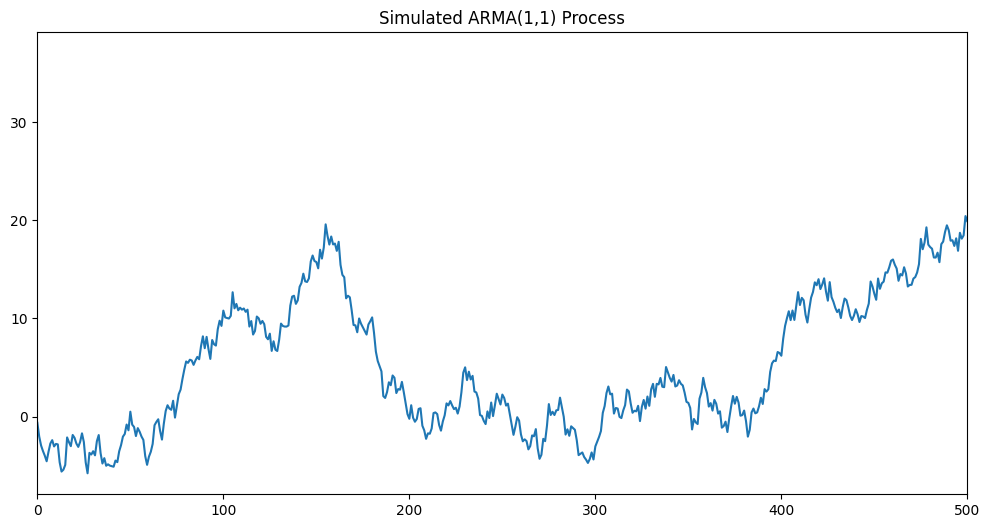

In [10]:
# Fitting the ARMA(1,1) model and deriving parameters

arma11_model = ARIMA(X, order=(1, 0, 1)).fit()
phi1_arma11 = arma11_model.params['ar.L1']
theta1_arma11 = arma11_model.params['ma.L1']

# Simulate ARMA(1,1) Process
ar1 = np.array([1, -phi1_arma11])
ma1 = np.array([1, theta1_arma11])
ARMA_1 = ArmaProcess(ar1, ma1).generate_sample(nsample=N)
plt.plot(ARMA_1)
plt.title('Simulated ARMA(1,1) Process')
plt.xlim([0, 500])
plt.show()

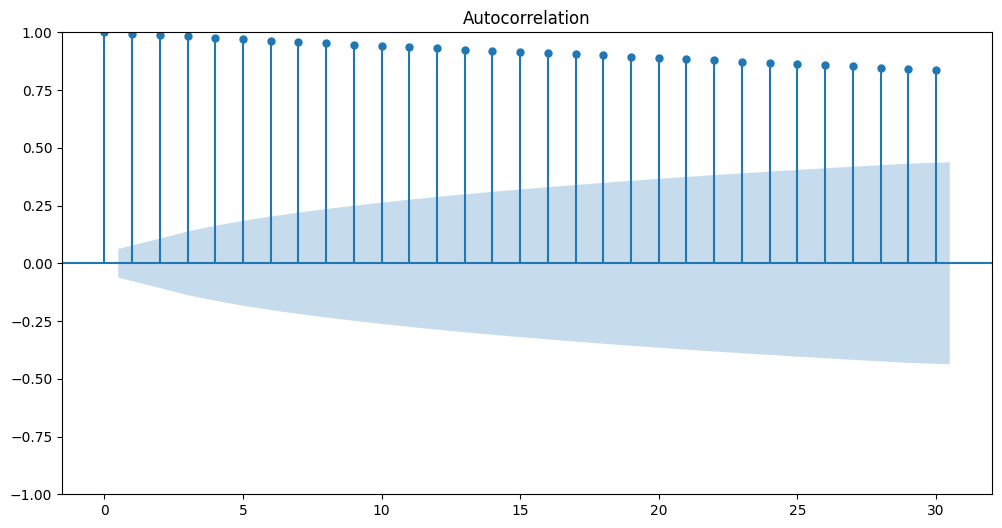

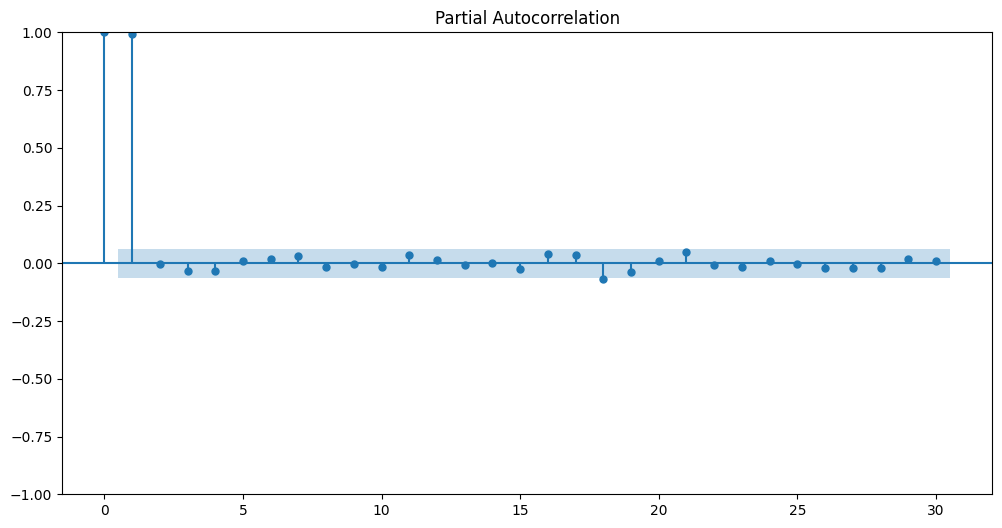

c:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive pa

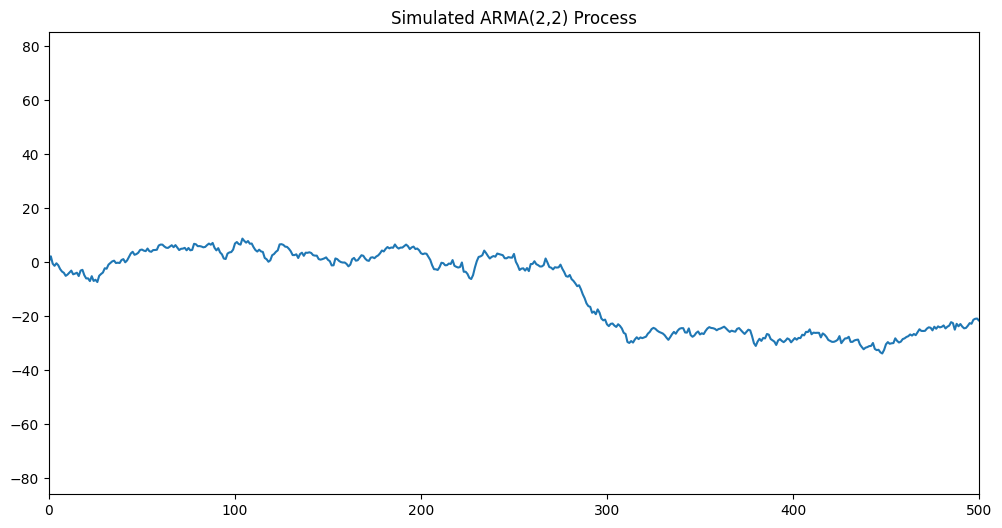

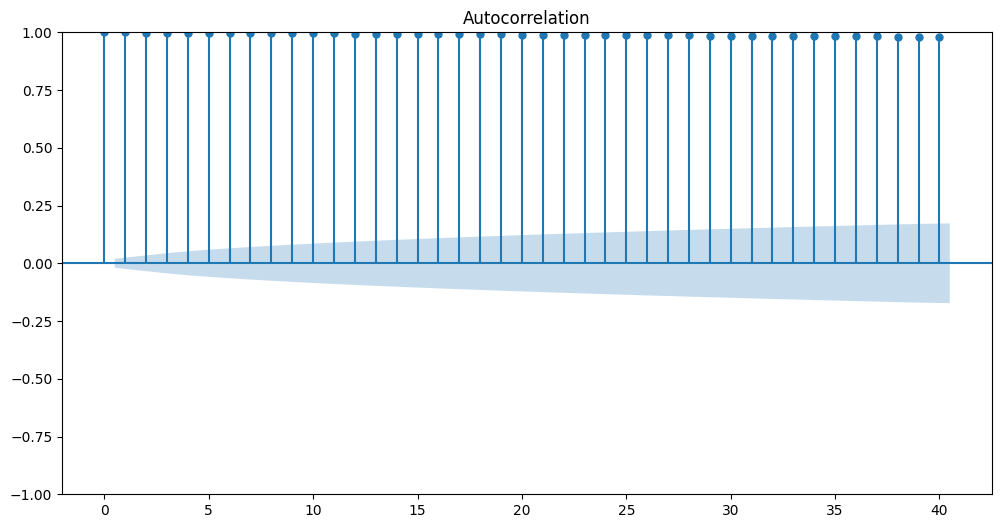

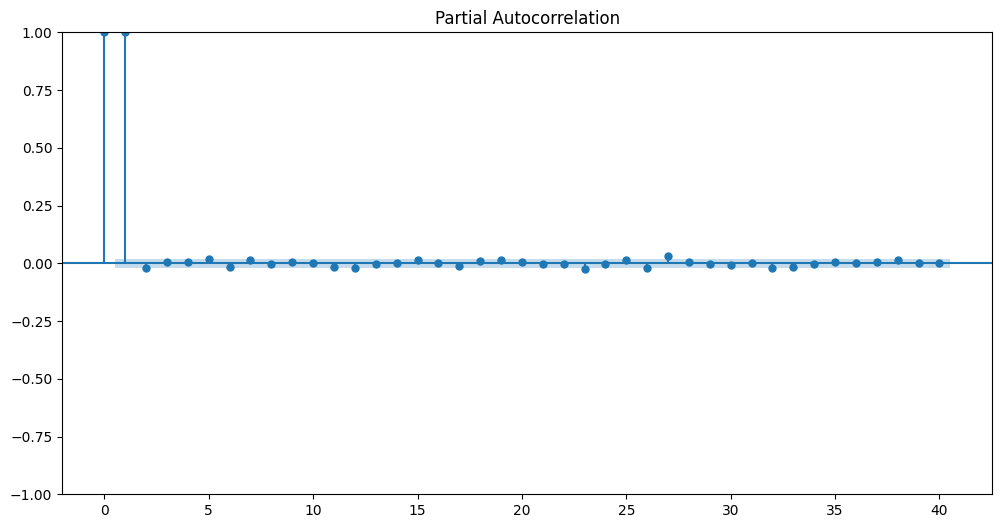

In [11]:
# Plot ACF and PACF for ARMA(1,1)
plot_acf(ARMA_1)
plt.show()
plot_pacf(ARMA_1)
plt.show()

# Fitting the ARMA(1,1) model and deriving parameters
arma22_model = ARIMA(X, order=(2, 0, 2)).fit()
phi1_arma22 = arma22_model.params['ar.L1']
phi2_arma22 = arma22_model.params['ar.L2']
theta1_arma22 = arma22_model.params['ma.L1']
theta2_arma22 = arma22_model.params['ma.L2']

# Simulate ARMA(2,2) Process
ar2 = np.array([1, -phi1_arma22, -phi2_arma22])  
ma2 = np.array([1, theta1_arma22, theta2_arma22])  
ARMA_2 = ArmaProcess(ar2, ma2).generate_sample(nsample=N*10)
plt.plot(ARMA_2)
plt.title('Simulated ARMA(2,2) Process')
plt.xlim([0, 500])
plt.show()

# Plot ACF and PACF for ARMA(2,2)
plot_acf(ARMA_2)
plt.show()
plot_pacf(ARMA_2)
plt.show()